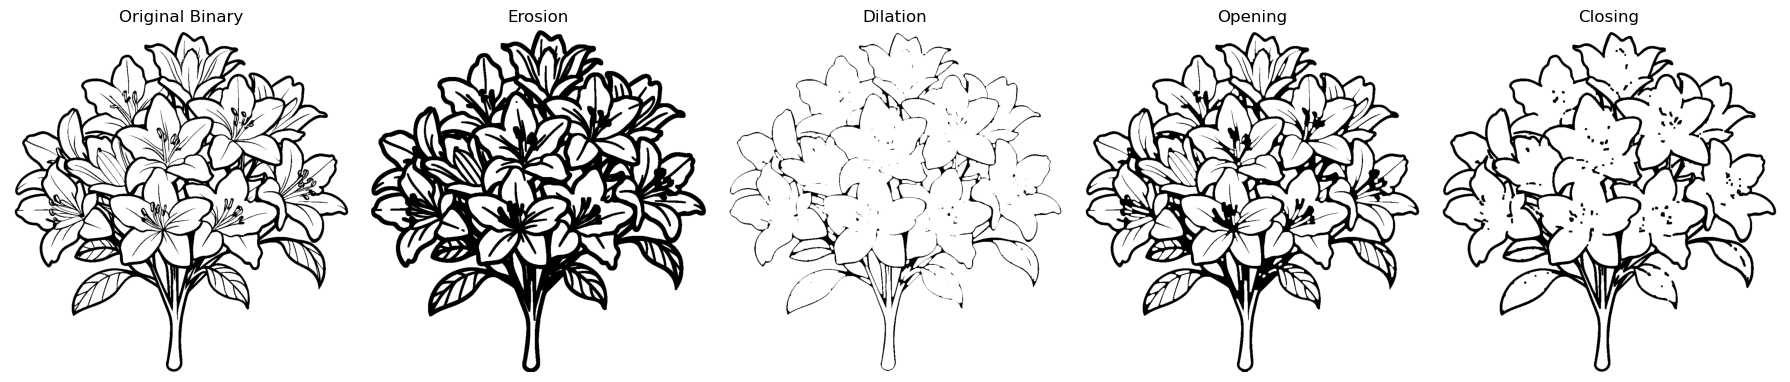

In [ ]:
#Write a Python program to demonstrate the application of basic morphological operations—Erosion, Dilation, Opening, and Closing.

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP: Specify your image path here
image_path = 'original_image.jpg'

# Load the image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not load image at {image_path}. Check the filename!")
else:
    # 2. PRE-PROCESSING: Convert to Binary (Black & White)
    # Using Otsu's thresholding to automatically find the best threshold value
    _, binary_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. DEFINE KERNEL: The "brush" used for operations (5x5 square)
    kernel = np.ones((5, 5), np.uint8)

    # 4. APPLY MORPHOLOGICAL OPERATIONS

    # Erosion: Shrinks white regions (removes thin lines/noise)
    eroded = cv2.erode(binary_img, kernel, iterations=1)

    # Dilation: Expands white regions (fills gaps/thickens lines)
    dilated = cv2.dilate(binary_img, kernel, iterations=1)

    # Opening: Erosion followed by Dilation (Removes noise outside objects)
    opened = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel)

    # Closing: Dilation followed by Erosion (Fills holes inside objects)
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel)

    # 5. DISPLAY RESULTS
    titles = ['Original Binary', 'Erosion', 'Dilation', 'Opening', 'Closing']
    images = [binary_img, eroded, dilated, opened, closed]

    plt.figure(figsize=(18, 8))

    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()